# Figures 2K-L

In [1]:
# Import libraries
from tkinter.filedialog import askdirectory
from tkinter import Tk
import os
os.environ["OUTDATED_IGNORE"] = "1"
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

cur_dir = Path(os.getcwd())
src_dir = cur_dir.parent.parent
os.chdir(src_dir)
from functions.scale_bars import add_scalebar
from functions.photom_plots import make_boxplot, plot_mean_over_trials, align_to_event
os.chdir(cur_dir)

############################################################
DS_rate = 10 #standard sampling rate of input data
############################################################

plt.rcParams['figure.figsize'] = [9,10.5] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams.update({'font.size': 16})

In [2]:
###############################
# Define which stimuli to plot:
StimsToPlot = ['chow']
my_colors = ['#ff7f0e']
DS = 10 #how much to downsample for plots
###############################
# Set these variables to determine how long before each event type to plot
ContactPreTime = 3 #in mins
BitePreTime = 3 #in mins
FinishPreTime = 5 #in mins
###############################

# Convert to seconds
ContactPreTime = ContactPreTime*60
FinishPreTime = FinishPreTime*60
BitePreTime = BitePreTime*60

# Open a dialog box to select the directory to be analyzed
# (so that this code block can be run independently of the merging block above)
window = Tk()
window.wm_attributes('-topmost', 1)
window.withdraw()
Dir2 = askdirectory(parent = window)
os.chdir(Dir2 + '/')

# Load data
with open('AllTrialsData.pkl', 'rb') as f:
    AllTrials = pickle.load(f)

In [3]:
# Initialize dataframe to contain mouse means (for dF/F0 AND z-score)
my_cols = pd.MultiIndex(levels = [[],[]], codes = [[],[]],
                            names = [u'Mouse',u'Stim'])
MouseMeans_Aligned = {}
MouseMeans_Aligned['dFF0'] = {}
MouseMeans_Aligned['dFF0']['Drop'] = pd.DataFrame(index = AllTrials['Drop_dFF0'].index, columns = my_cols)
MouseMeans_Aligned['ZS'] = {}
MouseMeans_Aligned['ZS']['Drop'] = pd.DataFrame(index = AllTrials['Drop_dFF0'].index, columns = my_cols)

for Mouse in list(set(AllTrials['MouseID'])): #loop through mice
    MouseTrials_dFF0 = AllTrials['Drop_dFF0'].xs(Mouse, level=0, axis=1) # take the trials from this mouse
    MouseTrials_ZS = AllTrials['Drop_ZS'].xs(Mouse, level=0, axis=1)
    # loop through unique stimulus IDs for this mouse
    for Stim in list(set(MouseTrials_dFF0.columns.get_level_values(1))):
        # return the trials for this stimulus
        ThisStimTrials_dFF0 = MouseTrials_dFF0.xs(Stim, level=1, axis=1)
        ThisStimTrials_ZS = MouseTrials_ZS.xs(Stim, level=1, axis=1)
        # calculate mean over trials for this mouse
        ThisMouseMean_dFF0 = pd.DataFrame(np.mean(ThisStimTrials_dFF0,1), 
                                                index=list(MouseTrials_dFF0.index), columns=pd.MultiIndex.from_arrays([[Mouse],[Stim]]))
        ThisMouseMean_ZS = pd.DataFrame(np.mean(ThisStimTrials_ZS,1), 
                                                index=list(MouseTrials_ZS.index), columns=pd.MultiIndex.from_arrays([[Mouse],[Stim]]))
        # add to dataframe
        MouseMeans_Aligned['dFF0']['Drop'] = pd.concat([MouseMeans_Aligned['dFF0']['Drop'],ThisMouseMean_dFF0], axis=1)
        MouseMeans_Aligned['ZS']['Drop'] = pd.concat([MouseMeans_Aligned['ZS']['Drop'],ThisMouseMean_ZS], axis=1)
        del(ThisMouseMean_dFF0,ThisMouseMean_ZS,ThisStimTrials_dFF0,ThisStimTrials_ZS)
    del(MouseTrials_dFF0,MouseTrials_ZS)

In [4]:
AllTrials, MouseMeans_Aligned = align_to_event(
    event = 'Contact', event_pretime = ContactPreTime, data=AllTrials, mouse_data=MouseMeans_Aligned
) # align to first contact with food
AllTrials, MouseMeans_Aligned = align_to_event(
    event = 'Bite', event_pretime = BitePreTime, data=AllTrials, mouse_data=MouseMeans_Aligned
) # align to first bite

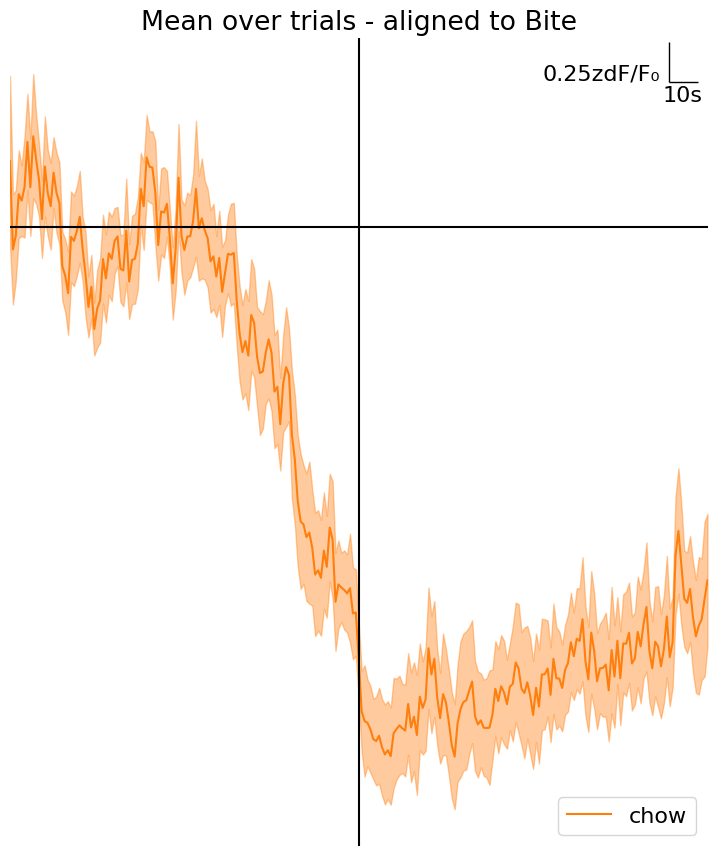

In [5]:
ShortTrials = {'Drop_ZS': AllTrials['Drop_ZS'].loc[-120:120],
               'Contact_ZS': AllTrials['Contact_ZS'].loc[-120:120],
               'Bite_ZS': AllTrials['Bite_ZS'].loc[-120:120]}

fig, ax = plot_mean_over_trials(Stims = StimsToPlot, Signal = 'ZS', AlignedTo = 'Bite', my_colors=my_colors, TrialData=ShortTrials, DS=DS)
add_scalebar(ax, matchx=False, matchy=False, sizex=10, sizey=0.25,
             labelx='10s', labely=u'0.25zdF/F\u2080', loc='upper right')
ax.axhline(0, color='black')
#fig.savefig('short_zs BiteAligned '+ ', '.join(StimsToPlot) + '_MeanOverTrials.png')
#fig.savefig('short_zs BiteAligned '+ ', '.join(StimsToPlot) + '_MeanOverTrials.pdf')

Text(0, 0.5, 'Mean zdF/F₀ in period')

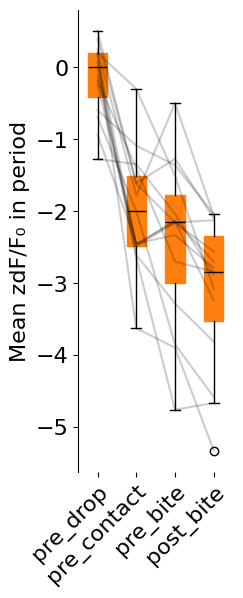

In [6]:
quant1 = pd.DataFrame(columns = ['pre_drop', 'pre_contact', 'pre_bite', 'post_bite'])

for ind, col in enumerate(AllTrials['Drop_ZS'].columns):
    pre_drop = AllTrials['Drop_ZS'][col][-30:-20].mean()
    pre_contact = AllTrials['Drop_ZS'][col][0:AllTrials['ContactInds'][ind]-1].mean()
    pre_bite = AllTrials['Drop_ZS'][col][AllTrials['ContactInds'][ind]:AllTrials['BiteInds'][ind]-1].mean()
    post_bite = AllTrials['Drop_ZS'][col][AllTrials['BiteInds'][ind]:AllTrials['BiteInds'][ind]+10].mean()
    quant1 = pd.concat([quant1, pd.DataFrame({'pre_drop': [pre_drop], 'pre_contact': [pre_contact],
                                             'pre_bite': [pre_bite], 'post_bite': [post_bite]},
                     index=['_'.join([col[0], col[1]])])
                     ])

fig, ax = make_boxplot(quant1, my_colors=['#ff7f0e','#ff7f0e','#ff7f0e','#ff7f0e'], connecting_lines=True)
_ = plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax.set_ylabel(u'Mean zdF/F\u2080 in period')
#fig.savefig('quantification_in_periods.png')
#fig.savefig('quantification_in_periods.pdf')

In [7]:
pg.rm_anova(quant1)

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,Within,3,42,51.876922,3.525731e-14,0.612463,0.704858


In [8]:
pg.ttest(quant1['pre_drop'],quant1['pre_contact'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,7.130443,14,two-sided,0.000005,"[1.29, 2.4]",2.721768,4041.668,1.0


In [9]:
pg.ttest(quant1['pre_contact'],quant1['pre_bite'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.73349,14,two-sided,0.104965,"[-0.1, 0.92]",0.420232,0.879,0.32898


In [10]:
pg.ttest(quant1['pre_bite'],quant1['post_bite'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.249402,14,two-sided,0.000123,"[0.42, 1.01]",0.659542,238.944,0.661561
